Using device: cpu
Epoch 1/5, Loss: 0.3570357612582412
Epoch 2/5, Loss: 0.14685445845222422
Epoch 3/5, Loss: 0.10069463921806165
Epoch 4/5, Loss: 0.07779534195692761
Epoch 5/5, Loss: 0.06011084603793077
Accuracy: 97.44%
Model saved as mnist_model.pth


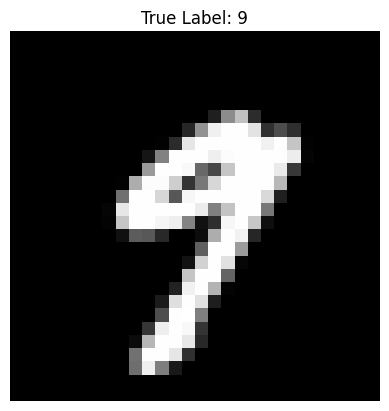

User picked image index 20
True Label: 9
Predicted Label: 9


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform=transforms.ToTensor() # convert images to tensor and normalize to [0,1] , [0,1] means that the pixel values are scaled to be between 0 and 1, which is a common preprocessing step for neural networks.

train_dataset = MNIST(root='./data', train=True, download=True, transform=transform) # saving the dataset in the ./data directory, if it doesn't exist, it will be created. The train=True argument specifies that we want the training set of the MNIST dataset. The download=True argument tells PyTorch to download the dataset if it's not already present in the specified root directory. The transform=transform argument applies the transformation defined earlier (converting images to tensors) to each image in the dataset.
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class DigitModel(nn.Module): # Define a simple neural network for digit classification
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(28*28, 128), # Input layer: 28*28 pixels to 128 hidden units
            nn.ReLU(), # Activation function: ReLU introduces non-linearity to the model, allowing it to learn complex patterns in the data.
            nn.Linear(128, 64), # Hidden layer: 128 hidden units to 64 hidden units
            nn.ReLU(), # Activation function: ReLU introduces non-linearity to the model, allowing it to learn complex patterns in the data.
            nn.Linear(64, 10) # Output layer: 64 hidden units to 10 output classes (digits 0-9)
        )

    def forward(self, x):
        return self.net(x)

model = DigitModel().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs=5

for epoch in range(epochs):
    model.train()
    total_loss=0

    for img,lable in train_loader:
        img=img.view(img.size(0),-1).to(device) # Reshape the image to a 1D tensor
        lable=lable.to(device) # Move the labels to the same device as the model (CPU or GPU)

        optimizer.zero_grad()
        output=model(img)
        loss=loss_fn(output,lable)
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader)}")

model.eval()
correct=0
total=0
with torch.no_grad():
    for img,lable in test_loader:
        img=img.view(img.size(0),-1).to(device)
        lable=lable.to(device)

        output=model(img)
        predicted=output.argmax(dim=1)
        total+=lable.size(0)
        correct+=(predicted==lable).sum().item()

print(f"Accuracy: {100*correct/total:.2f}%")

torch.save(model.state_dict(), "mnist_model.pth")
print("Model saved as mnist_model.pth")

index = 20
img, label = test_dataset[index]

plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"True Label: {label}")
plt.axis('off')
plt.show()

image_flat=img.view(1, -1).to(device)
with torch.no_grad():
    output=model(image_flat)
    predicted_label=output.argmax(dim=1).item()

print(f"User picked image index {index}")
print(f"True Label: {label}")
print(f"Predicted Label: {predicted_label}")
